# Laboratorio 4 — Análisis de Datos GeoEspaciales
## Cianobacteria en los lagos de Atitlán y Amatitlán (Sentinel-2)

**CC3084 – Data Science | Semestre II 2026**

Integrantes: 
- Daniel Oswaldo Juárez Herrera
- Humberto Alexander de la Cruz
- Nicolle Alexandra Gordillo

---

## Configuración

In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask
from scipy import ndimage
import matplotlib.pyplot as plt
import json

RAIZ = Path.cwd()
DIR_RAW     = RAIZ / "datos" / "raw"        # lo que baja 01_descarga.py
DIR_INDICES = RAIZ / "datos" / "indices"    # índices calculados (se generan aquí)
DIR_GEOJSON = RAIZ / "datos" / "geojson"    # opcional: límite oficial del lago
DIR_RES     = RAIZ / "resultados"
DIR_FIG     = DIR_RES / "figuras"
for d in (DIR_INDICES, DIR_GEOJSON, DIR_RES, DIR_FIG):
    d.mkdir(parents=True, exist_ok=True)

NOMBRE = {"atitlan": "Lago de Atitlán", "amatitlan": "Lago de Amatitlán"}
COLOR  = {"atitlan": "#1b6ca8", "amatitlan": "#c0392b"}

# Fechas oficiales con su nubosidad y satélite (tabla del enunciado)
ESCENAS = {
    "atitlan": [("2025-01-18",0.02,"S2B"), ("2025-04-13",0.54,"S2C"), ("2025-05-13",4.37,"S2C"),
                ("2025-07-17",3.57,"S2A"), ("2025-11-21",3.15,"S2A"), ("2025-12-29",3.17,"S2C"),
                ("2026-02-12",0.04,"S2B"), ("2026-03-24",3.17,"S2B"), ("2026-04-13",0.01,"S2B"),
                ("2026-04-28",4.96,"S2C"), ("2026-07-22",4.02,"S2B")],
    "amatitlan":[("2025-01-28",0.06,"S2B"), ("2025-04-15",0.09,"S2A"), ("2025-04-28",1.03,"S2B"),
                ("2025-11-24",0.50,"S2B"), ("2026-01-08",0.77,"S2C"), ("2026-02-02",0.39,"S2B"),
                ("2026-02-07",0.02,"S2C"), ("2026-03-29",0.01,"S2C"), ("2026-04-13",0.09,"S2B"),
                ("2026-04-28",4.96,"S2C"), ("2026-06-19",13.00,"S2A")],
}
LAGOS = list(ESCENAS)
BANDAS = ["B02","B03","B04","B05","B07","B08","B8A","B11","B12","SCL"]

# --- Umbrales 
SCL_INVALIDAS   = {0, 1, 3, 8, 9, 10}  # sin dato, saturado, sombra, nube, cirros
UMBRAL_FAI      = 0.08     # nata flotante (umbral del script original)
CHLA_ALTO       = 10.0     # µg/L, nivel de alerta 1 de la OMS para uso recreativo
CHLA_SEVERO     = 25.0     # µg/L, condición hipereutrófica
FRACCION_AGUA   = 0.5      # un píxel es "lago" si fue agua en >=X% de las fechas.
                           # Solo se usa si NO hay geojson. Si la máscara sale mucho
                           # más chica que el lago real, bajarlo a 0.2 (ver validación).
CHLA_MAX        = 500.0    # µg/L, tope del rango de calibración del modelo CyanoLakes
COBERTURA_MIN   = 40.0     # % del lago sin nube para considerar la fecha confiable

# Superficie oficial de cada lago, para validar la máscara (km²)
AREA_REAL = {"atitlan": 130.1, "amatitlan": 15.2}

MESES_LLUVIA = {5,6,7,8,9,10}
estacion = lambda f: "Lluviosa" if int(f[5:7]) in MESES_LLUVIA else "Seca"

CSV = DIR_RES / "estadisticas_por_fecha.csv"
ruta_raw     = lambda lago, f: DIR_RAW / lago / f"{lago}_{f}.tif"
ruta_indices = lambda lago, f: DIR_INDICES / lago / f"{lago}_{f}_indices.tif"

## Funciones base

### El índice de cianobacteria

Se usa el custom script oficial de Sentinel Hub **"Cyanobacteria Chlorophyll-a NDCI"**
(Kravitz & Matthews, 2020 — CyanoLakes):
<https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/>

El script hace tres cosas, que aquí se separan como capas de datos en vez de mezclarse
en una paleta de colores:

| Componente | Fórmula | Bandas |
|---|---|---|
| Máscara de agua (Mohor Gartner) | combinación de MNDWI, NDWI, AWEI, NDVI, DBSI | B02 B03 B04 B08 B11 B12 |
| Floating Algal Index (Hu, 2009) | `B07 − B04 − (B8A − B04)·(783−665)/(865−665)` | B04 B07 B8A |
| NDCI (Mishra & Mishra, 2012) | `(B05 − B04)/(B05 + B04)` | B04 B05 |
| Chl-a (calibración CyanoLakes) | `826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071` | — |

El **NDCI** es el índice de cianobacteria propiamente dicho (adimensional);
la **Chl-a en µg/L** es su traducción a una magnitud interpretable para ambientalistas.

In [58]:
def _div(a, b):
    "División segura: 0/0 -> NaN, sin warnings."
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.divide(a, b)
    r[~np.isfinite(r)] = np.nan
    return r.astype(np.float32)

def norm(x, y):
    "Índice normalizado genérico (x-y)/(x+y)."
    return _div(x - y, x + y)

def mascara_agua_wbi(b02, b03, b04, b08, b11, b12):
    "Detección de cuerpos de agua del script CyanoLakes (técnica de Mohor Gartner)."
    r, g, b, nir, swir1, swir2 = b04, b03, b02, b08, b11, b12
    ndvi_       = norm(nir, r)
    mndwi       = norm(g, swir1)
    ndwi_       = norm(g, nir)
    ndwi_leaves = norm(nir, swir1)
    aweish  = b + 2.5*g - 1.5*(nir + swir1) - 0.25*swir2
    aweinsh = 4*(g - swir1) - (0.25*nir + 2.75*swir1)
    dbsi    = norm(swir1, g) - ndvi_
    agua = ((mndwi > 0.42) | (ndwi_ > 0.40) | (aweinsh > 0.1879)
            | (aweish > 0.1112) | (ndvi_ < -0.2) | (ndwi_leaves > 1))
    agua = np.nan_to_num(agua, nan=False).astype(bool)
    # filtra zonas urbanas y suelo desnudo
    no_agua = np.nan_to_num((aweinsh <= -0.03) | (dbsi > 0), nan=False).astype(bool)
    return agua & ~no_agua

def calcular_indices(b):
    "Recibe un dict de bandas en reflectancia 0-1 y devuelve todas las capas derivadas."
    # Control de calidad: en agua oscura la reflectancia corregida (L2A) puede salir
    # negativa o casi cero. Ahí el denominador del índice normalizado se acerca a cero
    # y el NDCI se dispara fuera de su rango físico [-1, 1], generando falsas
    # floraciones. Esos píxeles se descartan antes de calcular nada.
    ok = (b["B04"] > 0) & (b["B05"] > 0)
    ndci = np.clip(np.where(ok, norm(b["B05"], b["B04"]), np.nan), -1, 1)
    chla = np.clip(826.57*ndci**3 - 176.43*ndci**2 + 19*ndci + 4.071, 0, CHLA_MAX)
    fai  = b["B07"] - b["B04"] - (b["B8A"] - b["B04"])*(783-665)/(865-665)
    return {
        "ndci": ndci.astype(np.float32),
        "chla": chla.astype(np.float32),
        "fai":  fai.astype(np.float32),
        "nata": np.nan_to_num(fai > UMBRAL_FAI, nan=False).astype(bool),
        "ndci_ok": ok,
        "ndvi": norm(b["B08"], b["B04"]),
        "ndwi": norm(b["B03"], b["B08"]),
        "agua": mascara_agua_wbi(b["B02"], b["B03"], b["B04"], b["B08"], b["B11"], b["B12"]),
    }

### Lectura de imágenes y máscara del lago

**Por qué la máscara del lago se congela.** Una floración densa hace que el agua se
comporte ópticamente como vegetación: el NDWI baja y el NDVI sube. Si se recalculara
la máscara de agua en cada fecha, justo los píxeles con floración quedarían fuera del
análisis y se subestimaría el fenómeno. Por eso un píxel pertenece al lago si fue agua
en al menos el 50 % de las fechas válidas, y esa máscara se usa igual en todas las
fechas: así el número de píxeles del lago es constante y los porcentajes entre fechas
son comparables.

In [59]:
def leer_escena(lago, fecha):
    "Devuelve (bandas en reflectancia 0-1, máscara de píxeles válidos, perfil rasterio)."
    ruta = ruta_raw(lago, fecha)
    if not ruta.exists():
        return None, None, None
    with rasterio.open(ruta) as src:
        datos, perfil = src.read().astype(np.float32), src.profile.copy()
    b = {n: datos[i] for i, n in enumerate(BANDAS)}

    scl = b.pop("SCL")
    valido = ~np.isin(np.rint(scl).astype(np.int16), list(SCL_INVALIDAS))

    # openEO entrega enteros 0-10000; se detecta y escala automáticamente
    m = b["B04"][np.isfinite(b["B04"])]
    if m.size and np.nanpercentile(m, 99) > 1.5:
        b = {k: v/10000.0 for k, v in b.items()}

    sin_dato = np.all(np.stack(list(b.values())) == 0, axis=0)  # borde de la órbita
    return b, valido & ~sin_dato, perfil

def mascara_lago(lago, fechas, perfil):
    "Límite del lago: geojson si existe, si no consenso temporal de agua."
    gj = DIR_GEOJSON / f"{lago}.geojson"
    if gj.exists():
        d = json.loads(gj.read_text(encoding="utf-8"))
        geoms = [f["geometry"] for f in d.get("features", [])] or [d["geometry"]]
        m = geometry_mask(geoms, out_shape=(perfil["height"], perfil["width"]),
                          transform=perfil["transform"], invert=True)
        print(f"  máscara desde geojson: {m.sum():,} píxeles")
        return m

    acum_agua = acum_val = None
    for f in fechas:
        b, val, _ = leer_escena(lago, f)
        if b is None:
            continue
        agua = mascara_agua_wbi(b["B02"], b["B03"], b["B04"], b["B08"], b["B11"], b["B12"]) & val
        if acum_agua is None:
            acum_agua = np.zeros(agua.shape, np.int16); acum_val = np.zeros(agua.shape, np.int16)
        acum_agua += agua; acum_val += val

    frec = np.divide(acum_agua, np.maximum(acum_val, 1), dtype=np.float32)
    m = (frec >= FRACCION_AGUA) & (acum_val >= 3)
    m = ndimage.binary_opening(m, structure=np.ones((3,3)))   # quita píxeles sueltos
    m = ndimage.binary_fill_holes(m)                          # rellena huecos con nata
    et, n = ndimage.label(m)
    if n > 1:                                                 # se queda con el lago principal
        m = et == (int(np.argmax(ndimage.sum(m, et, range(1, n+1)))) + 1)
    print(f"  máscara estable: {m.sum():,} píxeles de agua")
    return m

def area_km2(mascara, perfil):
    "Superficie de la máscara en km², para comprobar que corresponde al lago real."
    tr = perfil["transform"]
    lat = tr.f + tr.e * perfil["height"] / 2          # latitud del centro
    dx = abs(tr.a) * 111320 * np.cos(np.radians(lat))  # metros por píxel (este-oeste)
    dy = abs(tr.e) * 110540                            # metros por píxel (norte-sur)
    return float(mascara.sum()) * dx * dy / 1e6

def guardar_tif(ruta, arrays, nombres, perfil):
    p = perfil.copy()
    p.update(driver="GTiff", dtype="float32", count=len(arrays), compress="deflate", nodata=np.nan)
    ruta.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(ruta, "w", **p) as dst:
        for i, (a, n) in enumerate(zip(arrays, nombres), 1):
            dst.write(a.astype(np.float32), i); dst.set_band_description(i, n)

In [60]:
import urllib.request, urllib.parse, json, time

CONSULTAS = {"atitlan": "Lago de Atitlán, Guatemala",
             "amatitlan": "Lago de Amatitlán, Guatemala"}

def bajar_geojson(lago, consulta):
    url = ("https://nominatim.openstreetmap.org/search?"
           + urllib.parse.urlencode({"q": consulta, "format": "json",
                                     "polygon_geojson": 1, "limit": 5}))
    req = urllib.request.Request(url, headers={"User-Agent": "UVG-CC3084-Lab4"})
    with urllib.request.urlopen(req, timeout=30) as r:
        res = json.load(r)
    poly = [x for x in res
            if x.get("geojson", {}).get("type") in ("Polygon", "MultiPolygon")]
    if not poly:
        print(f"{lago}: no se encontró polígono"); return
    mejor = poly[0]
    fc = {"type": "FeatureCollection",
          "features": [{"type": "Feature",
                        "properties": {"name": mejor.get("display_name"),
                                       "fuente": "OpenStreetMap (ODbL)"},
                        "geometry": mejor["geojson"]}]}
    (DIR_GEOJSON / f"{lago}.geojson").write_text(json.dumps(fc), encoding="utf-8")
    print(f"{lago}: {mejor['geojson']['type']} guardado — "
          f"{mejor.get('display_name','')[:60]}")

for lago, consulta in CONSULTAS.items():
    bajar_geojson(lago, consulta)
    time.sleep(1)   # Nominatim pide máximo 1 consulta por segundo

atitlan: Polygon guardado — Lago de Atitlán, San Pedro La Laguna, Sololá, 07013, Guatema
amatitlan: Polygon guardado — Lago de Amatitlán, Villa Canales, Departamento de Guatemala,


---
# Ejercicio 3 — Índice de cianobacteria, NDVI y NDWI

Se aplica el script de cianobacteria a las 11 fechas de cada lago y se guardan
dos productos: un GeoTIFF por fecha con todas las capas (lo usan las secciones
de análisis espacial) y una tabla resumen con una fila por lago-fecha.

In [61]:
CAPAS = ["ndci","chla","fai","ndvi","ndwi","agua","valido","nata"]

def procesar(lago):
    print(f"=== {NOMBRE[lago]} ===")
    escenas = [e for e in ESCENAS[lago] if ruta_raw(lago, e[0]).exists()]
    faltan  = [e[0] for e in ESCENAS[lago] if not ruta_raw(lago, e[0]).exists()]
    if faltan: print(f"  AVISO: faltan {len(faltan)} fechas por descargar: {', '.join(faltan)}")
    if not escenas: print("  No hay imágenes. Corra antes 01_descarga.py"); return []

    _, _, perfil = leer_escena(lago, escenas[0][0])
    lago_m = mascara_lago(lago, [e[0] for e in escenas], perfil)
    area, esperada = area_km2(lago_m, perfil), AREA_REAL[lago]
    print(f"  superficie detectada: {area:.1f} km² (real ≈ {esperada} km², "
          f"{100*area/esperada:.0f}%)")
    if area < 0.8 * esperada:
        print("  *** AVISO: la máscara deja fuera parte del lago. Use el geojson del "
              "curso (datos/geojson/<lago>.geojson) o baje FRACCION_AGUA a 0.2 ***")
    guardar_tif(DIR_INDICES / f"mascara_{lago}.tif", [lago_m.astype(np.float32)],
                ["mascara_lago"], perfil)

    filas = []
    for fecha, nub, sat in escenas:
        b, val, perfil = leer_escena(lago, fecha)
        if b["B04"].shape != lago_m.shape:
            print(f"  [ERROR] {fecha}: dimensiones distintas, vuelva a descargarla"); continue
        c = calcular_indices(b)
        n_lago = int(lago_m.sum())
        cob = 100 * int((lago_m & val).sum()) / max(n_lago, 1)   # cobertura sin nubes
        sel = lago_m & val & c["ndci_ok"]   # además, índice físicamente válido
        n_val = int(sel.sum())
        descartados = int((lago_m & val & ~c["ndci_ok"]).sum())

        fila = dict(lago=lago, fecha=fecha, anio=int(fecha[:4]), mes=int(fecha[5:7]),
                    estacion=estacion(fecha), satelite=sat, nubosidad_escena_pct=nub,
                    pixeles_lago=n_lago, pixeles_validos=n_val,
                    cobertura_valida_pct=round(cob, 2),
                    pct_descartado_ndci=round(100*descartados/max(n_lago, 1), 2),
                    confiable=(cob >= COBERTURA_MIN) and (100*descartados/max(n_lago,1) < 20))
        if n_val:
            ndci_v, chla_v = c["ndci"][sel], c["chla"][sel]
            fila.update(
                ndci_media=float(np.nanmean(ndci_v)), ndci_mediana=float(np.nanmedian(ndci_v)),
                ndci_p90=float(np.nanpercentile(ndci_v, 90)),
                chla_media=float(np.nanmean(chla_v)), chla_mediana=float(np.nanmedian(chla_v)),
                chla_p90=float(np.nanpercentile(chla_v, 90)),
                ndvi_media=float(np.nanmean(c["ndvi"][sel])),
                ndwi_media=float(np.nanmean(c["ndwi"][sel])),
                fai_media=float(np.nanmean(c["fai"][sel])),
                pct_chla_alto=100*float(np.nanmean(chla_v >= CHLA_ALTO)),
                pct_chla_severo=100*float(np.nanmean(chla_v >= CHLA_SEVERO)),
                pct_nata=100*float(np.nanmean(c["nata"][sel])))
        filas.append(fila)

        guardar_tif(ruta_indices(lago, fecha),
                    [c["ndci"], c["chla"], c["fai"], c["ndvi"], c["ndwi"],
                     c["agua"].astype(np.float32), val.astype(np.float32),
                     c["nata"].astype(np.float32)], CAPAS, perfil)
        print(f"  {fecha}: cobertura {cob:5.1f}%  NDCI {fila.get('ndci_media', np.nan):+.3f}  "
              f"Chl-a mediana {fila.get('chla_mediana', np.nan):5.1f} µg/L  "
              f"floración {fila.get('pct_chla_alto', np.nan):5.1f}% del lago  "
              f"(descartado {fila['pct_descartado_ndci']:.1f}%)")
    return filas

df = pd.DataFrame([f for lago in LAGOS for f in procesar(lago)]).sort_values(["lago","fecha"])
df.to_csv(CSV, index=False)
print(f"\nGuardado: {CSV}")
df.head()

=== Lago de Atitlán ===
  máscara desde geojson: 261,558 píxeles
  superficie detectada: 124.5 km² (real ≈ 130.1 km², 96%)
  2025-01-18: cobertura 100.0%  NDCI -0.147  Chl-a mediana   0.0 µg/L  floración  19.2% del lago  (descartado 75.5%)
  2025-04-13: cobertura 100.0%  NDCI -0.028  Chl-a mediana   3.4 µg/L  floración   1.0% del lago  (descartado 0.0%)
  2025-05-13: cobertura 100.0%  NDCI -0.012  Chl-a mediana   3.9 µg/L  floración   1.2% del lago  (descartado 0.0%)
  2025-07-17: cobertura 100.0%  NDCI +0.013  Chl-a mediana   4.3 µg/L  floración   2.3% del lago  (descartado 0.2%)
  2025-11-21: cobertura 100.0%  NDCI -0.069  Chl-a mediana   2.7 µg/L  floración   7.8% del lago  (descartado 4.9%)
  2025-12-29: cobertura  99.9%  NDCI -0.084  Chl-a mediana   1.4 µg/L  floración   3.3% del lago  (descartado 5.7%)
  2026-02-12: cobertura 100.0%  NDCI -0.055  Chl-a mediana   3.2 µg/L  floración   3.7% del lago  (descartado 15.0%)
  2026-03-24: cobertura 100.0%  NDCI -0.011  Chl-a mediana   3.

,lago,fecha,anio,mes,estacion,satelite,nubosidad_escena_pct,pixeles_lago,pixeles_validos,cobertura_valida_pct,...,ndci_p90,chla_media,chla_mediana,chla_p90,ndvi_media,ndwi_media,fai_media,pct_chla_alto,pct_chla_severo,pct_nata
11,amatitlan,2025-01-28,2025,1,Seca,S2B,0.06,31453,31447,100.0,...,0.367521,16.336002,12.361238,28.255611,-0.385445,0.583557,0.002119,64.600757,13.517983,0.457913
12,amatitlan,2025-04-15,2025,4,Seca,S2A,0.09,31453,31453,100.0,...,0.298372,8.683571,5.282250,15.989225,-0.072799,0.260133,0.003967,21.524179,4.536928,0.613614
13,amatitlan,2025-04-28,2025,4,Seca,S2B,1.03,31453,31452,100.0,...,0.385459,14.050944,6.602442,32.519474,-0.033973,0.252757,0.008575,38.706601,14.838484,0.976091
14,amatitlan,2025-11-24,2025,11,Seca,S2B,0.50,31453,31450,100.0,...,0.375615,14.434000,6.631646,30.119211,-0.356246,0.518337,0.003769,29.580286,12.047695,1.252782
15,amatitlan,2026-01-08,2026,1,Seca,S2C,0.77,31453,31446,100.0,...,0.448963,26.248211,15.985305,51.840382,-0.075616,0.334802,0.006447,77.634675,30.442664,1.618648


### 3.1 Control de calidad

Antes de interpretar nada hay que comprobar dos cosas: que la máscara corresponde
al lago real y que ningún índice quedó fuera de su rango físico. El NDCI es un
índice normalizado, así que **cualquier valor fuera de [-1, 1] indica un problema
de datos, no una floración**.

OK: todas las fechas tienen el NDCI dentro del rango físico [-1, 1].

Píxeles descartados por reflectancia negativa o nula (% del lago):


lago,amatitlan,atitlan
fecha,,
2025-01-18,NaN,75.47
2025-01-28,0.02,NaN
2025-04-13,NaN,0.00
2025-04-15,0.00,NaN
2025-04-28,0.00,NaN
2025-05-13,NaN,0.01
2025-07-17,NaN,0.17
2025-11-21,NaN,4.89
2025-11-24,0.01,NaN


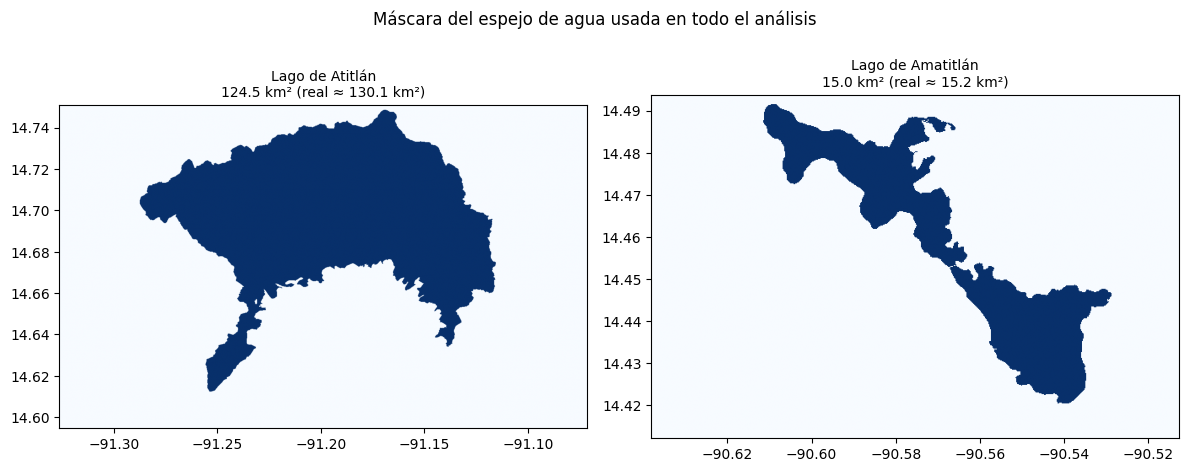

In [62]:
# --- 1. Rango físico del NDCI ---
malos = df[(df.ndci_p90.abs() > 1) | (df.ndci_media.abs() > 1)]
if len(malos):
    print("PROBLEMA: hay fechas con NDCI fuera de [-1, 1]:")
    display(malos[["lago","fecha","ndci_media","ndci_p90"]])
else:
    print("OK: todas las fechas tienen el NDCI dentro del rango físico [-1, 1].")

# --- 2. Píxeles descartados por reflectancia inválida ---
print("\nPíxeles descartados por reflectancia negativa o nula (% del lago):")
display(df.pivot_table(index="fecha", columns="lago", values="pct_descartado_ndci"))

# --- 3. Mapa de la máscara de cada lago ---
fig, axes = plt.subplots(1, len(LAGOS), figsize=(12, 5))
for ax, lago in zip(np.atleast_1d(axes), LAGOS):
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as s:
        m, bd, perfil = s.read(1), s.bounds, s.profile
    ax.imshow(m, extent=(bd[0], bd[2], bd[1], bd[3]), origin="upper", cmap="Blues")
    ax.set_title(f"{NOMBRE[lago]}\n{area_km2(m.astype(bool), perfil):.1f} km² "
                 f"(real ≈ {AREA_REAL[lago]} km²)", fontsize=10)
fig.suptitle("Máscara del espejo de agua usada en todo el análisis")
fig.tight_layout(); fig.savefig(DIR_FIG / "mascaras_lagos.png", dpi=150); plt.show()

### 3.2 Mapa del índice generado, por lago

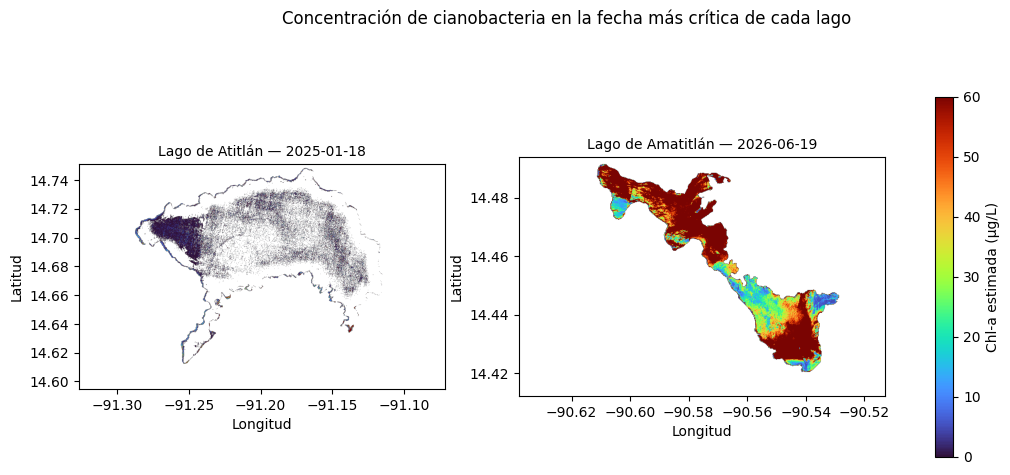

In [63]:
def mapa_chla(lago, fecha, ax=None, vmax=60):
    with rasterio.open(ruta_indices(lago, fecha)) as src:
        chla, val = src.read(2), src.read(7).astype(bool)
        izq, abajo, der, arriba = src.bounds
    with rasterio.open(DIR_INDICES / f"mascara_{lago}.tif") as src:
        lago_m = src.read(1).astype(bool)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(np.where(lago_m & val, chla, np.nan),
                   extent=(izq, der, abajo, arriba), origin="upper",
                   cmap="turbo", vmin=0, vmax=vmax)
    ax.set_title(f"{NOMBRE[lago]} — {fecha}", fontsize=10)
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, lago in zip(axes, LAGOS):
    sub = df[df.lago == lago].dropna(subset=["chla_media"])
    peor = sub.loc[sub.chla_media.idxmax(), "fecha"]
    im = mapa_chla(lago, peor, ax=ax)
fig.colorbar(im, ax=axes, label="Chl-a estimada (µg/L)", shrink=0.85)
fig.suptitle("Concentración de cianobacteria en la fecha más crítica de cada lago")
fig.savefig(DIR_FIG / "mapas_indice_por_lago.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Ejercicio 4 — Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

In [64]:
df = pd.read_csv(CSV, parse_dates=["fecha"]).sort_values(["lago","fecha"])

# Se reporta la MEDIANA de Chl-a, no la media: la conversión NDCI -> Chl-a es un
# polinomio de grado 3, así que unos pocos píxeles extremos disparan el promedio y
# lo vuelven poco representativo del lago.
tabla = df.pivot_table(index="fecha", columns="lago",
                       values=["ndci_media","chla_mediana","pct_chla_alto"]).round(3)
display(tabla)

resumen = (df[df.confiable]
           .groupby("lago")
           .agg(fechas=("fecha","count"),
                ndci_medio=("ndci_media","mean"),
                chla_mediana=("chla_mediana","median"),
                chla_p90_max=("chla_p90","max"),
                pct_lago_afectado=("pct_chla_alto","mean"),
                fechas_con_floracion=("pct_chla_alto", lambda s: int((s > 20).sum())))
           .round(2))
display(resumen)
resumen.to_csv(DIR_RES / "resumen_por_lago.csv")

chla_mediana         ndci_media         pct_chla_alto        
lago          amatitlan atitlan  amatitlan atitlan     amatitlan atitlan
fecha                                                                   
2025-01-18          NaN   0.000        NaN  -0.147           NaN  19.179
2025-01-28       12.361     NaN      0.270     NaN        64.601     NaN
2025-04-13          NaN   3.356        NaN  -0.028           NaN   1.025
2025-04-15        5.282     NaN      0.141     NaN        21.524     NaN
2025-04-28        6.602     NaN      0.195     NaN        38.707     NaN
2025-05-13          NaN   3.858        NaN  -0.012           NaN   1.160
2025-07-17          NaN   4.275        NaN   0.013           NaN   2.302
2025-11-21          NaN   2.677        NaN  -0.069           NaN   7.802
2025-11-24        6.632     NaN      0.208     NaN        29.580     NaN
2025-12-29          NaN   1.412        NaN  -0.084           NaN   3.291
2026-01-08       15.985     NaN      0.311     NaN        77.635     NaN
2026-02-02        5.371     NaN      0.137     NaN         8.142     NaN
2026-02-07        7.072     NaN      0.203     NaN        22.805     NaN
2026-02-12          NaN   3.247        NaN  -0.055           NaN   3.670
2026-03-24          NaN   3.828        NaN  -0.011           NaN   1.168
2026-03-29       10.391     NaN      0.255     NaN        52.623     NaN
2026-04-13       14.179   4.236      0.289   0.008        81.390   1.265
2026-04-28       18.180   3.608      0.276  -0.020        55.419   1.152
2026-06-19       59.271     NaN      0.448     NaN        95.825     NaN
2026-07-22          NaN   4.218        NaN   0.010           NaN   1.959

,fechas,ndci_medio,chla_mediana,chla_p90_max,pct_lago_afectado,fechas_con_floracion
lago,,,,,,
amatitlan,11,0.25,10.39,107.21,49.84,10
atitlan,10,-0.02,3.72,7.85,2.48,0


### 4.2 Evolución temporal y 4.3 picos de floración

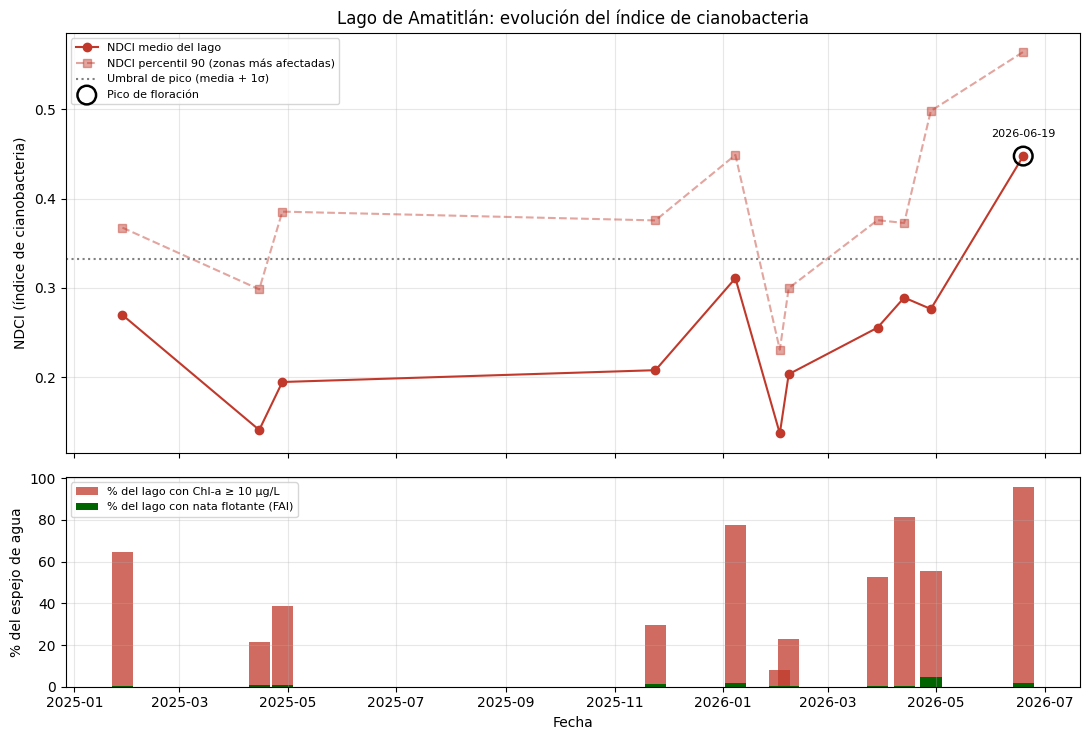

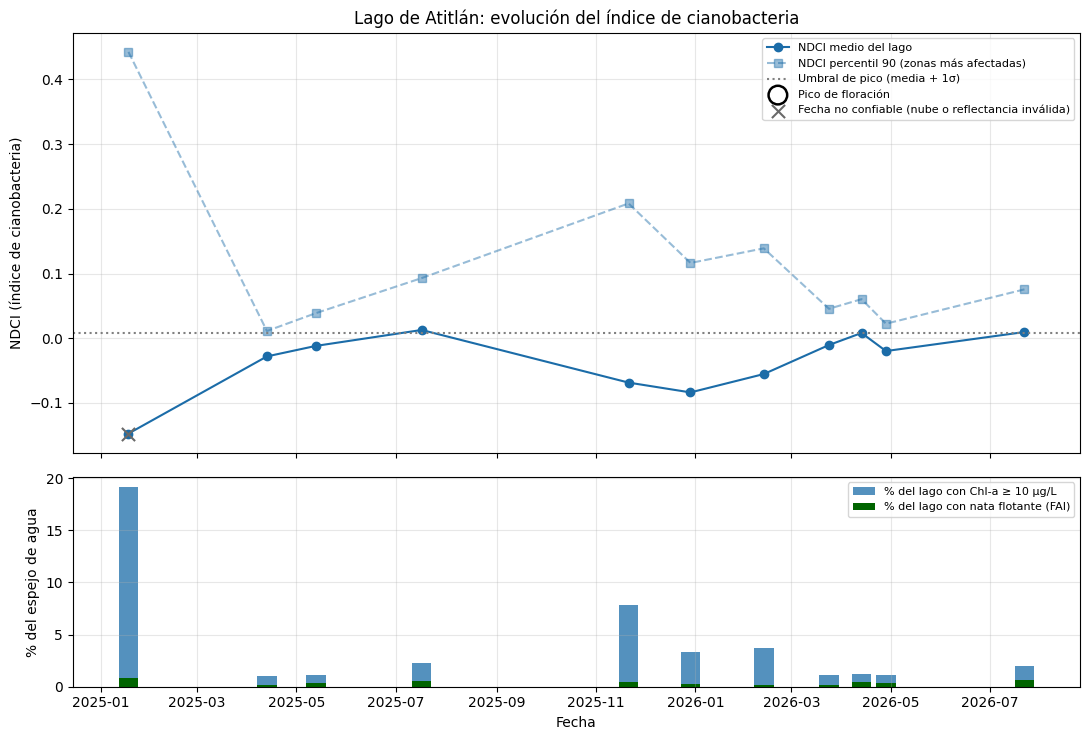

Fechas críticas detectadas:


,lago,fecha,ndci_media,chla_media,pct_chla_alto
10,amatitlan,2026-06-19,0.447697,61.50758,95.825252


In [65]:
def marcar_picos(sub, col="ndci_media", k=1.0):
    "Pico = máximo local que además supera la media del lago + 1 desviación estándar."
    conf = sub[sub.confiable]
    umbral = conf[col].mean() + k*conf[col].std(ddof=0)
    v = sub[col].to_numpy()
    local = np.array([np.isfinite(v[i])
                      and v[i] >= (v[i-1] if i else -np.inf)
                      and v[i] >= (v[i+1] if i < len(v)-1 else -np.inf)
                      for i in range(len(v))])
    sub = sub.copy()
    sub["umbral_pico"] = umbral
    sub["es_pico"] = ((sub[col] >= umbral) & local & sub.confiable
                      & (sub.pct_chla_alto >= 10))    # un pico debe afectar >=10% del lago
    return sub

df = pd.concat([marcar_picos(s) for _, s in df.groupby("lago")]).sort_values(["lago","fecha"])

for lago, sub in df.groupby("lago"):
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True,
                                 gridspec_kw={"height_ratios":[2,1]})
    a1.plot(sub.fecha, sub.ndci_media, "-o", color=COLOR[lago], label="NDCI medio del lago")
    a1.plot(sub.fecha, sub.ndci_p90, "--s", color=COLOR[lago], alpha=.45,
            label="NDCI percentil 90 (zonas más afectadas)")
    a1.axhline(sub.umbral_pico.iloc[0], color="gray", ls=":", label="Umbral de pico (media + 1σ)")
    picos = sub[sub.es_pico]
    a1.scatter(picos.fecha, picos.ndci_media, s=180, facecolors="none", edgecolors="k",
               linewidths=1.8, zorder=5, label="Pico de floración")
    for _, r in picos.iterrows():
        a1.annotate(r.fecha.strftime("%Y-%m-%d"), (r.fecha, r.ndci_media),
                    textcoords="offset points", xytext=(0,14), ha="center", fontsize=8)
    malas = sub[~sub.confiable]
    if len(malas):
        a1.scatter(malas.fecha, malas.ndci_media, marker="x", s=90, color="dimgray",
                   zorder=6, label="Fecha no confiable (nube o reflectancia inválida)")
    a1.set_ylabel("NDCI (índice de cianobacteria)"); a1.grid(alpha=.3); a1.legend(fontsize=8)
    a1.set_title(f"{NOMBRE[lago]}: evolución del índice de cianobacteria")

    a2.bar(sub.fecha, sub.pct_chla_alto, width=12, color=COLOR[lago], alpha=.75,
           label=f"% del lago con Chl-a ≥ {CHLA_ALTO:.0f} µg/L")
    a2.bar(sub.fecha, sub.pct_nata, width=12, color="darkgreen",
           label="% del lago con nata flotante (FAI)")
    a2.set_ylabel("% del espejo de agua"); a2.set_xlabel("Fecha")
    a2.grid(alpha=.3); a2.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(DIR_FIG / f"serie_temporal_{lago}.png", dpi=150)
    plt.show()

print("Fechas críticas detectadas:")
display(df[df.es_pico][["lago","fecha","ndci_media","chla_media","pct_chla_alto"]])
df.to_csv(DIR_RES / "serie_temporal_cianobacteria.csv", index=False)

### Números de referencia para la interpretación

In [66]:
# Genera los números concretos que se citan en la interpretación del 4.4.
for lago, sub in df.groupby("lago"):
    conf = sub[sub.confiable].dropna(subset=["ndci_media"])
    print(f"\n=== {NOMBRE[lago]} ===")
    print(f"NDCI medio del período: {conf.ndci_media.mean():+.3f} "
          f"(rango {conf.ndci_media.min():+.3f} a {conf.ndci_media.max():+.3f})")
    print(f"Chl-a mediana típica: {conf.chla_mediana.median():.1f} µg/L | "
          f"máximo percentil 90: {conf.chla_p90.max():.1f} µg/L")
    print(f"Superficie afectada: media {conf.pct_chla_alto.mean():.1f}%, "
          f"máxima {conf.pct_chla_alto.max():.1f}% del lago")
    print(f"Fechas con floración extendida (>20% del lago): "
          f"{int((conf.pct_chla_alto > 20).sum())} de {len(conf)}")
    print("Tres fechas más afectadas:")
    for _, r in conf.nlargest(3, "pct_chla_alto").iterrows():
        print(f"   {r.fecha.date()} — {r.pct_chla_alto:5.1f}% del lago, "
              f"Chl-a mediana {r.chla_mediana:.1f} µg/L ({r.estacion.lower()})")
    for est in ("Seca", "Lluviosa"):
        g = conf[conf.estacion == est]
        if len(g):
            print(f"   Época {est.lower():9s}: NDCI medio {g.ndci_media.mean():+.3f} "
                  f"| {g.pct_chla_alto.mean():5.1f}% del lago afectado (n={len(g)})")


=== Lago de Amatitlán ===
NDCI medio del período: +0.248 (rango +0.137 a +0.448)
Chl-a mediana típica: 10.4 µg/L | máximo percentil 90: 107.2 µg/L
Superficie afectada: media 49.8%, máxima 95.8% del lago
Fechas con floración extendida (>20% del lago): 10 de 11
Tres fechas más afectadas:
   2026-06-19 —  95.8% del lago, Chl-a mediana 59.3 µg/L (lluviosa)
   2026-04-13 —  81.4% del lago, Chl-a mediana 14.2 µg/L (seca)
   2026-01-08 —  77.6% del lago, Chl-a mediana 16.0 µg/L (seca)
   Época seca     : NDCI medio +0.228 |  45.2% del lago afectado (n=10)
   Época lluviosa : NDCI medio +0.448 |  95.8% del lago afectado (n=1)

=== Lago de Atitlán ===
NDCI medio del período: -0.025 (rango -0.084 a +0.013)
Chl-a mediana típica: 3.7 µg/L | máximo percentil 90: 7.8 µg/L
Superficie afectada: media 2.5%, máxima 7.8% del lago
Fechas con floración extendida (>20% del lago): 0 de 10
Tres fechas más afectadas:
   2025-11-21 —   7.8% del lago, Chl-a mediana 2.7 µg/L (seca)
   2026-02-12 —   3.7% del lag

### 4.4 Interpretación de los patrones temporales

- Los límites de ambos lagos provienen de OpenStreetMap (ODbL), y cubren el 96 % de la superficie oficial de Atitlán y el 99 % de la de Amatitlán. La imagen de Atitlán del 18 de enero de 2025 se excluye del análisis: perdió el 75.5 % de sus píxeles por reflectancia inválida.

**Los dos lagos se comportan de manera radicalmente distinta.** Amatitlán presenta un
índice de cianobacteria positivo en las once fechas analizadas, con media de +0.248 y un
rango de +0.137 a +0.448. Atitlán se mantiene alrededor de cero (media de −0.025) y no
registra ninguna fecha con floración extendida. No es una diferencia de grado sino de
régimen: en Amatitlán la presencia de cianobacteria es la condición permanente del lago y
lo que varía es su intensidad; en Atitlán es un fenómeno marginal.

**La evidencia más contundente son las dos fechas en que ambos lagos fueron observados el
mismo día.** El 13 de abril de 2026, la floración cubría el 81.4 % de Amatitlán y el 1.3 %
de Atitlán. El 28 de abril de 2026 las cifras fueron 55.4 % y 1.2 %. Al eliminar cualquier
diferencia de estación, clima o condiciones de captura, la comparación queda atribuida a
las características propias de cada cuerpo de agua.

**En Amatitlán la floración es crónica, no episódica.** Diez de las once fechas superan el
20 % de superficie afectada, y en promedio la mitad del lago (49.8 %) presenta niveles de
clorofila-a por encima del umbral de alerta. Incluso la fecha menos afectada de toda la
serie —el 2 de febrero de 2026— mantenía el 8.1 % del espejo de agua en esas condiciones:
nunca se observó el lago limpio. La clorofila-a mediana del lago es de 10.4 µg/L, es decir
que **la mitad del lago está habitualmente en el umbral de alerta o por encima**, y las
zonas más afectadas superan los 100 µg/L.

**Dentro del período se observa un agravamiento.** Desde febrero de 2026 la serie sube de
forma sostenida: 8.1 %, 22.8 %, 52.6 %, 81.4 %, 55.4 % y 95.8 % en junio, el máximo de todo
el registro con una mediana de 59.3 µg/L. La comparación entre meses equivalentes apunta en
la misma dirección: enero pasó de 64.6 % en 2025 a 77.6 % en 2026, y abril de 21.5 % y
38.7 % en 2025 a 81.4 % y 55.4 % en 2026. Con once observaciones no se puede afirmar una
tendencia en sentido estadístico, pero el patrón es consistente en todas las fechas
comparables y merece seguimiento.

**En Atitlán no se observan floraciones extendidas.** Ninguna de las diez fechas utilizables
supera el 20 % de superficie afectada; el valor más alto es 7.8 % (21/11/2025), seguido de
3.7 % (12/02/2026) y 3.3 % (29/12/2025). La clorofila-a mediana ronda los 3.7 µg/L, un nivel
propio de aguas poco productivas, y las zonas más afectadas apenas llegan a 7.8 µg/L. Esto
es consistente con las características del lago: es profundo, de gran volumen y con mayor
capacidad de dilución, de modo que los nutrientes que llegan se reparten en una masa de agua
mucho mayor.

**Fechas críticas.** El único episodio que el criterio estadístico marca como pico es el
**19 de junio de 2026** en Amatitlán. Por extensión de la floración, le siguen el 13 de
abril de 2026 (81.4 %) y el 8 de enero de 2026 (77.6 %). En Atitlán no se identifica ninguna
fecha crítica.

**Factores que podrían explicar lo observado.** Amatitlán es un lago somero que recibe la
descarga de la cuenca del río Villalobos, la más urbanizada del país, con aportes continuos
de aguas residuales y nutrientes desde el área metropolitana. Su poca profundidad implica
que el agua se calienta más, se estratifica con facilidad y que los nutrientes acumulados en
el sedimento vuelven a la columna de agua con relativa frecuencia. Que el lago nunca aparezca
limpio indica que el aporte de nutrientes es continuo y no depende de eventos puntuales.
Atitlán, en cambio, es profundo, de cuenca cerrada y con una presión urbana mucho menor por
unidad de volumen, lo que explica que la señal se mantenga baja de forma consistente.

**Sobre la estacionalidad no se puede concluir todavía.** De las once fechas de Amatitlán,
diez corresponden a época seca y solo una a época lluviosa —justamente el máximo de la
serie—, de modo que cualquier comparación entre estaciones estaría determinada por esa
única observación. Atitlán tiene una repartición algo mejor (siete y tres) pero sus valores
son tan bajos que no permiten distinguir un patrón.

**Limitaciones que deben acompañar cualquier conclusión.**

- Solo hay once fechas por lago en año y medio, seleccionadas por su baja nubosidad; no
  constituyen una serie continua ni permiten hablar de tendencia estadística.
- Las fechas casi no coinciden entre lagos (solo dos en común) ni se reparten de forma
  pareja entre estaciones.
- La imagen de Atitlán del 18/01/2025 fue descartada por reflectancia inválida en tres
  cuartas partes del lago.
- Los límites de los lagos provienen de OpenStreetMap, no de una fuente oficial
  guatemalteca; cubren el 96 % y el 99 % de la superficie reportada.
- El satélite solo detecta la capa superficial del agua: una población que se hunda por
  efecto del viento o de su propia flotabilidad pasa inadvertida, de modo que los mínimos no
  implican ausencia del organismo en el lago.
- La conversión del índice a clorofila-a en µg/L es empírica, calibrada con datos
  sintéticos y sin ajuste local. Sirve para comparar fechas y zonas entre sí; las cifras
  absolutas son estimaciones, no mediciones.